In [98]:
# Importing the Libraries:
import pandas as pd
import matplotlib.pyplot as plt

# Loading the Dataset:
df_olympics = pd.read_csv("olympics_08_medalists.csv")
df_olympics.head()

# Inspecting the Data:
df_olympics.info()
df_olympics.columns

# Printing the Original Untidy Dataset:
print("Original (Untidy) Olympics DataFrame:")
print(df_olympics.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1875 entries, 0 to 1874
Data columns (total 71 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   medalist_name                 1875 non-null   object
 1   male_archery                  11 non-null     object
 2   female_archery                9 non-null      object
 3   male_athletics                85 non-null     object
 4   female_athletics              81 non-null     object
 5   male_badminton                12 non-null     object
 6   female_badminton              10 non-null     object
 7   male_baseball                 72 non-null     object
 8   male_basketball               35 non-null     object
 9   female_basketball             36 non-null     object
 10  male_boxing                   44 non-null     object
 11  male_canoeing and kayaking    53 non-null     object
 12  female_canoeing and kayaking  21 non-null     object
 13  male_road bicycle 

In [99]:
# Cleaning the Data using melt. 
# Converting medal columns into one column called "Medal_Info"
# and their values into "Count".
df_olympics_melted = pd.melt(
    df_olympics,
    id_vars = ["medalist_name"],
    var_name = "Medal_Info",
    value_name = "Count")

print("\nMelted (Partially Tidy) Olympics DataFrame:")
print(df_olympics_melted.head())


Melted (Partially Tidy) Olympics DataFrame:
       medalist_name    Medal_Info Count
0    Aaron Armstrong  male_archery   NaN
1      Aaron Peirsol  male_archery   NaN
2   Abdullo Tangriev  male_archery   NaN
3  Abeer Abdelrahman  male_archery   NaN
4            Abhinav  male_archery   NaN


In [100]:
# Splitting the columns using "str.split()":
# Splitting "Medal_Info" into two columns:
df_olympics_melted[["Medal", "Category"]] = df_olympics_melted["Medal_Info"].str.split('_', expand = True)

print("\nAfter Splitting Columns:")
print(df_olympics_melted.head())


After Splitting Columns:
       medalist_name    Medal_Info Count Medal Category
0    Aaron Armstrong  male_archery   NaN  male  archery
1      Aaron Peirsol  male_archery   NaN  male  archery
2   Abdullo Tangriev  male_archery   NaN  male  archery
3  Abeer Abdelrahman  male_archery   NaN  male  archery
4            Abhinav  male_archery   NaN  male  archery


In [101]:
# Final Tidy DataFrame:
tidy_olympics = df_olympics_melted[["medalist_name", "Medal", "Category", "Count"]]

print("\nFinal (Tidy) Olympics DataFrame:")
print(tidy_olympics.head())


Final (Tidy) Olympics DataFrame:
       medalist_name Medal Category Count
0    Aaron Armstrong  male  archery   NaN
1      Aaron Peirsol  male  archery   NaN
2   Abdullo Tangriev  male  archery   NaN
3  Abeer Abdelrahman  male  archery   NaN
4            Abhinav  male  archery   NaN


In [102]:
tidy_olympics

,medalist_name,Medal,Category,Count
0,Aaron Armstrong,male,archery,NaN
1,Aaron Peirsol,male,archery,NaN
2,Abdullo Tangriev,male,archery,NaN
3,Abeer Abdelrahman,male,archery,NaN
4,Abhinav,male,archery,NaN
...,...,...,...,...
131245,Éver Banega,male,greco-roman wrestling,NaN
131246,Ólafur Stefánsson,male,greco-roman wrestling,NaN
131247,Óscar Brayson,male,greco-roman wrestling,NaN
131248,Łukasz Pawłowski,male,greco-roman wrestling,NaN


In [103]:
tidy_olympics.dropna(inplace = True)

C:\Users\lawso\AppData\Local\Temp\ipykernel_25152\821239295.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tidy_olympics.dropna(inplace = True)


In [104]:
# Visualization 1 - Total Medals by country:

# Inspecting data before dropping anything:
print(tidy_olympics.head(10))
print(tidy_olympics['Count'].unique())

# Cleaning the count column properly:
print(tidy_olympics['Count'].isna().sum())
print(len(tidy_olympics))

# Plotting the values:
medalist_name_totals = tidy_olympics.groupby('medalist_name')['Count'].sum()
tidy_olympics


       medalist_name Medal Category   Count
177     Bair Badënov  male  archery  bronze
676    Ilario Di Buò  male  archery  silver
682     Im Dong-hyun  male  archery    gold
760        Jiang Lin  male  archery  bronze
920   Lee Chang-hwan  male  archery    gold
950       Li Wenquan  male  archery  bronze
1043  Marco Galiazzo  male  archery  silver
1107   Mauro Nespoli  male  archery  silver
1314   Park Kyung-mo  male  archery  silver
1710    Viktor Ruban  male  archery    gold
['bronze' 'silver' 'gold']
0
1875


,medalist_name,Medal,Category,Count
177,Bair Badënov,male,archery,bronze
676,Ilario Di Buò,male,archery,silver
682,Im Dong-hyun,male,archery,gold
760,Jiang Lin,male,archery,bronze
920,Lee Chang-hwan,male,archery,gold
...,...,...,...,...
130932,Steeve Guénot,male,greco-roman wrestling,gold
131159,Yannick Szczepaniak,male,greco-roman wrestling,bronze
131162,Yavor Yanakiev,male,greco-roman wrestling,bronze
131200,Yury Patrikeyev,male,greco-roman wrestling,bronze


Medal
female     843
male      1032
dtype: int64


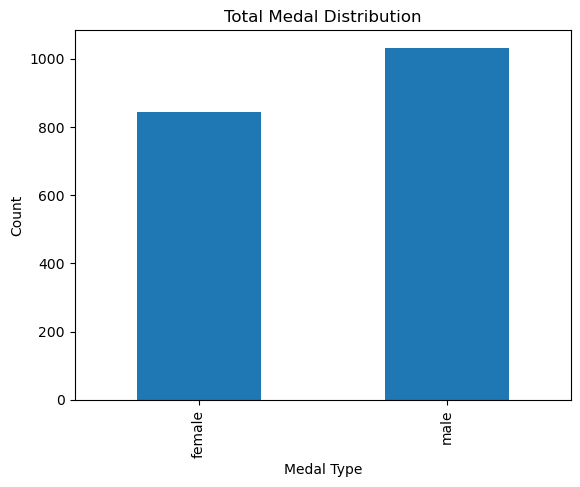

In [105]:
# Visualization 2 - Medal Distrubutor:
#medal_counts = tidy_olympics[["Medal", "Count"]].groupby(by = ['Medal']).agg(['count'])
medal_counts = tidy_olympics.groupby("Medal").size()
print(medal_counts) 

medal_counts.plot(kind="bar")

plt.title("Total Medal Distribution")
plt.xlabel("Medal Type")
plt.ylabel("Count")
plt.show()

In [106]:
# Pivot Table:
# Summarizes medal counts by type
# Demonstrates aggregation on tidy data

pivot = pd.pivot_table(
    tidy_olympics,
    values='Count',
    index='medalist_name',
    columns='Medal',
    aggfunc='sum'
)

pivot.head()



Medal,female,male
medalist_name,,
Aaron Armstrong,NaN,gold
Aaron Peirsol,NaN,gold
Abdullo Tangriev,NaN,silver
Abeer Abdelrahman,bronze,NaN
Abhinav,NaN,gold
